In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import os
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import datetime
import sys

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
import subprocess

from utils_for_analysis import (
    calculate_ss_for_df_and_factors,
    load_df_all,
    load_df_with_budget,
    discretized_parameter_scale,
    xlabel_dict,
    ylabel_dict,
    title_fontsize,
    label_fontsize,
    tick_fontsize,
    legend_fontsize,
    original_parameter_scale,
    color_map
)

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'code')))
from example_run_jobs import *

plt.rcParams['svg.fonttype'] = 'none'

base_path = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/"

In [21]:
def run_mut_comparision_anova_and_plot(
    df, 
    dataset_name, 
    feature_name, 
    mutations, 
    mutation_factor_colname, 
    results, 
    do_plot=False,
    verbose=False,
    train=False,
    aggregate=True,
    save=True,
    fig_path=None,
):
    feature = feature_name
    comparison_type = "train" if train else "test"
    
    if do_plot:
        col_size = 1.35
        row_size = col_size * len(mutations)
        fig, axes = plt.subplots(
            1,
            len(mutations),
            figsize=(8, 1.65),
            constrained_layout=True
        )
        title_fontsize = globals().get('title_fontsize', 9)
        label_fontsize = globals().get('label_fontsize', 8)
        tick_fontsize = globals().get('tick_fontsize', 7)
        legend_fontsize = globals().get('legend_fontsize', 7)
        if len(mutations) == 1:
            axes = [axes]
    for idx, train_muts in enumerate(mutations):
        df_plot = df[df[mutation_factor_colname] == train_muts]
        grouped = [group[feature].dropna().values for name, group in df_plot.groupby("model_name")]
        
        # Default values for both tests
        f_stat, p_value = None, None
        k_stat, k_p_value = None, None

        if len(grouped) > 1 and all(len(g) > 1 for g in grouped):
            # ANOVA
            f_stat, p_value = stats.f_oneway(*grouped)
            # Kruskal-Wallis
            k_stat, k_p_value = stats.kruskal(*grouped)
            if verbose:
                print(
                    f"### F = {f_stat:.3f}, p = {p_value:.3f} (ANOVA) | "
                    f"Kruskal-Wallis H = {k_stat:.3f}, p = {k_p_value:.3f}"
                )
        else:
            f_stat, p_value = None, None
            k_stat, k_p_value = None, None

        if aggregate:
            results.setdefault("feature", []).append(feature)
            results.setdefault("comparison_type", []).append(comparison_type)
            results.setdefault("mutations", []).append(train_muts)
            results.setdefault("dataset", []).append(dataset_name)
            # Store both ANOVA and Kruskal-Wallis results
            results.setdefault("F_value", []).append(f_stat)
            results.setdefault("P_value", []).append(p_value)
            results.setdefault("Kruskal_H", []).append(k_stat)
            results.setdefault("Kruskal_P", []).append(k_p_value)

        if do_plot:
            ax = axes[idx]
            palette = {m: color_map[m] for m in df_plot['model_name'].unique() if m in color_map}
            box_data = [df_plot[df_plot["model_name"] == model][feature].dropna().values for model in df_plot["model_name"].unique()]
            model_names = df_plot["model_name"].unique()
            bp = ax.boxplot(
                box_data,
                patch_artist=True,
                boxprops=dict(linewidth=1, color='black'),
                medianprops=dict(color='black', linewidth=1),
                whiskerprops=dict(linewidth=1, color='black'),
                capprops=dict(linewidth=1, color='black'),
                flierprops=dict(markerfacecolor='black', marker="o", markersize=3.5, alpha=0.8, linestyle='none', markeredgecolor='none')
            )
            for patch, model in zip(bp['boxes'], model_names):
                patch.set_facecolor(palette.get(model, "#cccccc"))

            
            ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.set_xticks(range(1, len(model_names) + 1))
            ax.set_xticklabels("")
            ax.set_xlabel(xlabel_dict.get('model_name', 'Model Name'), fontsize=label_fontsize, labelpad=3)
            title_str = f'Mutations in {comparison_type}: {train_muts}'
            # Optionally, annotate test results on the plot
            subtitle_strs = []
            if f_stat is not None and p_value is not None:
                subtitle_strs.append(f"ANOVA p={p_value:.2g}")
            if k_stat is not None and k_p_value is not None:
                subtitle_strs.append(f"KW p={k_p_value:.2g}")
            if subtitle_strs:
                title_str += "\n" + ", ".join(subtitle_strs)
            ax.set_title(title_str, fontsize=8, pad=5)
            ax.tick_params(axis='x', labelsize=tick_fontsize)
            ax.tick_params(axis='y', labelsize=tick_fontsize)
            if idx == 0:
                ax.set_ylabel(ylabel_dict.get(feature, feature), labelpad=6, fontsize=label_fontsize)
            else:
                ax.set_ylabel('')

    if fig_path is not None:
        plt.savefig(fig_path, format='svg')
    if do_plot:
        plt.show()
    return results

In [22]:
anova_agg = {
    "feature": [],
    "comparison_type": [],
    "mutations": [],
    "dataset": [],
    "F_value": [],
    "P_value": [],
    "Kruskal_H": [],
    "Kruskal_P": []
}


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: progen2-small_flat at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/progen2-small_flat
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/gfp/gfp_regression_optimal/progen2-small_flat
Reading CSV file: progen2-small_evaluation_train_on_4.csv
Reading CSV file: progen2-small_evaluation_train_on_3.csv
Reading CSV file: progen2

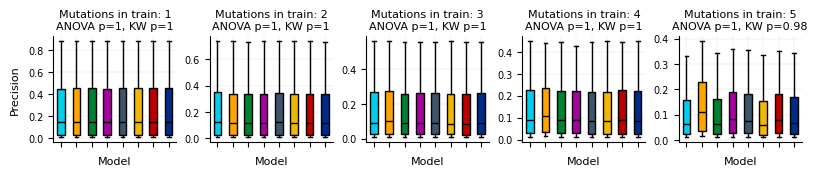

### F = 0.004, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.291, p = 0.989
### F = 0.005, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.687, p = 0.998
### F = 0.004, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.242, p = 1.000
### F = 0.022, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.403, p = 1.000
### F = 0.119, p = 0.996 (ANOVA) | Kruskal-Wallis H = 0.487, p = 0.999
### F = 0.261, p = 0.965 (ANOVA) | Kruskal-Wallis H = 0.714, p = 0.998


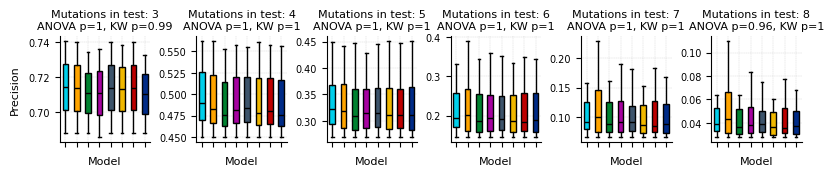

### F = 0.344, p = 0.930 (ANOVA) | Kruskal-Wallis H = 4.235, p = 0.752
### F = 1.842, p = 0.097 (ANOVA) | Kruskal-Wallis H = 16.471, p = 0.021
### F = 0.399, p = 0.898 (ANOVA) | Kruskal-Wallis H = 5.723, p = 0.572
### F = 0.167, p = 0.990 (ANOVA) | Kruskal-Wallis H = 1.440, p = 0.984
### F = 0.490, p = 0.835 (ANOVA) | Kruskal-Wallis H = 4.358, p = 0.738


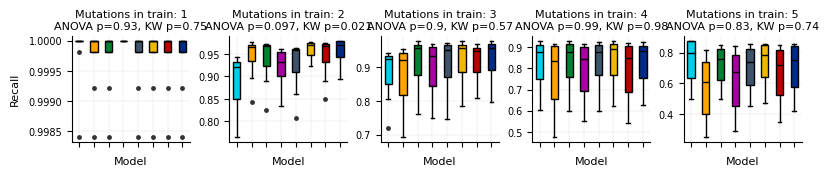

### F = 0.058, p = 0.999 (ANOVA) | Kruskal-Wallis H = 0.408, p = 1.000
### F = 0.258, p = 0.962 (ANOVA) | Kruskal-Wallis H = 2.050, p = 0.957
### F = 0.120, p = 0.996 (ANOVA) | Kruskal-Wallis H = 1.496, p = 0.982
### F = 0.074, p = 0.999 (ANOVA) | Kruskal-Wallis H = 1.280, p = 0.989
### F = 0.191, p = 0.985 (ANOVA) | Kruskal-Wallis H = 1.033, p = 0.994
### F = 0.193, p = 0.985 (ANOVA) | Kruskal-Wallis H = 1.044, p = 0.994


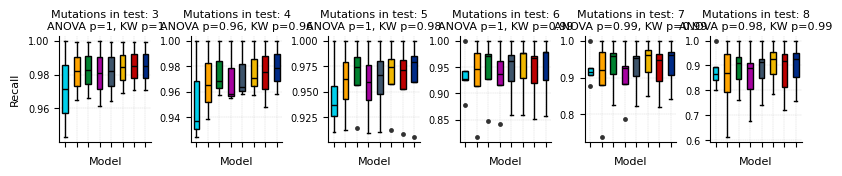

### F = 0.000, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.322, p = 1.000
### F = 0.000, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.486, p = 0.999
### F = 0.001, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.724, p = 0.998
### F = 0.003, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.505, p = 0.999
### F = 0.033, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.422, p = 0.985


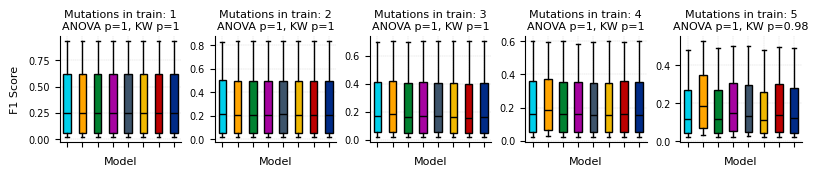

### F = 0.023, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.384, p = 0.986
### F = 0.001, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.545, p = 0.999
### F = 0.003, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.353, p = 1.000
### F = 0.015, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.403, p = 1.000
### F = 0.090, p = 0.999 (ANOVA) | Kruskal-Wallis H = 0.487, p = 0.999
### F = 0.223, p = 0.977 (ANOVA) | Kruskal-Wallis H = 0.734, p = 0.998


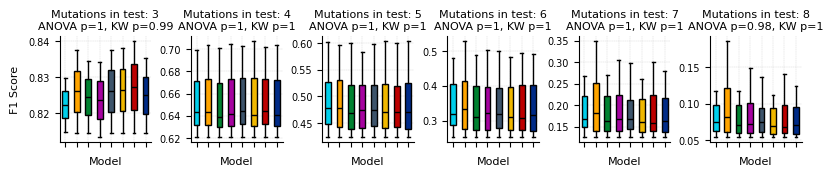

### F = 10.764, p = 0.000 (ANOVA) | Kruskal-Wallis H = 39.564, p = 0.000
### F = 0.419, p = 0.886 (ANOVA) | Kruskal-Wallis H = 6.209, p = 0.516
### F = 0.214, p = 0.980 (ANOVA) | Kruskal-Wallis H = 6.097, p = 0.529
### F = 0.047, p = 1.000 (ANOVA) | Kruskal-Wallis H = 2.595, p = 0.920
### F = 0.026, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.103, p = 0.993


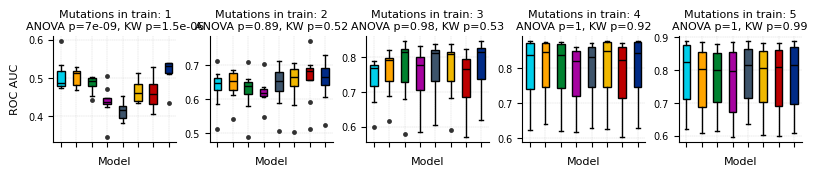

### F = 0.063, p = 0.999 (ANOVA) | Kruskal-Wallis H = 2.956, p = 0.889
### F = 0.026, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.107, p = 0.993
### F = 0.023, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.807, p = 0.997
### F = 0.029, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.465, p = 1.000
### F = 0.038, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.191, p = 0.991
### F = 0.056, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.490, p = 0.983


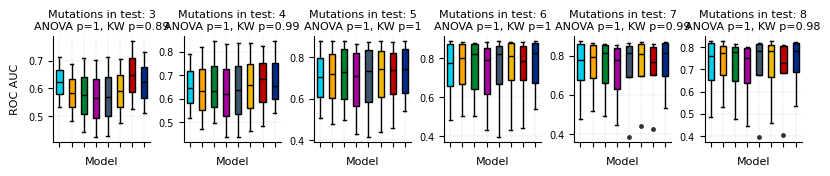

### F = 0.000, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.322, p = 1.000
### F = 0.175, p = 0.989 (ANOVA) | Kruskal-Wallis H = 6.344, p = 0.500
### F = 0.768, p = 0.617 (ANOVA) | Kruskal-Wallis H = 13.086, p = 0.070
### F = 3.736, p = 0.003 (ANOVA) | Kruskal-Wallis H = 18.898, p = 0.009
### F = 25.271, p = 0.000 (ANOVA) | Kruskal-Wallis H = 33.846, p = 0.000


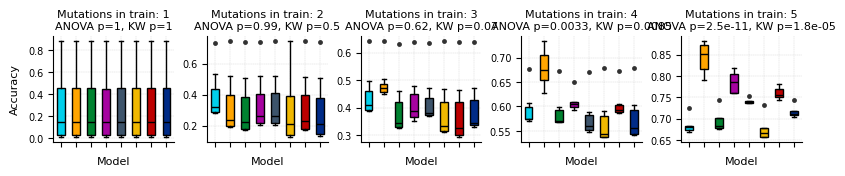

### F = 0.007, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.048, p = 0.994
### F = 0.004, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.599, p = 0.999
### F = 0.008, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.247, p = 1.000
### F = 0.014, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.368, p = 1.000
### F = 0.042, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.519, p = 0.999
### F = 0.068, p = 0.999 (ANOVA) | Kruskal-Wallis H = 0.675, p = 0.999


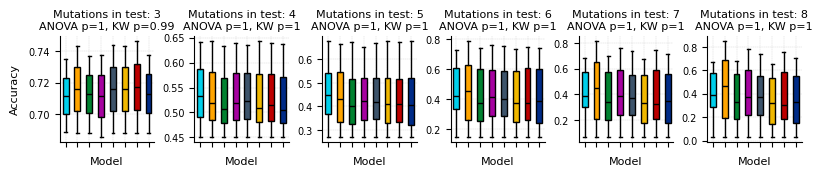

### F = 0.207, p = 0.983 (ANOVA) | Kruskal-Wallis H = 2.836, p = 0.900
### F = 0.261, p = 0.966 (ANOVA) | Kruskal-Wallis H = 2.787, p = 0.904
### F = 0.094, p = 0.998 (ANOVA) | Kruskal-Wallis H = 0.901, p = 0.996
### F = 0.106, p = 0.998 (ANOVA) | Kruskal-Wallis H = 1.398, p = 0.986
### F = 0.027, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.721, p = 0.998


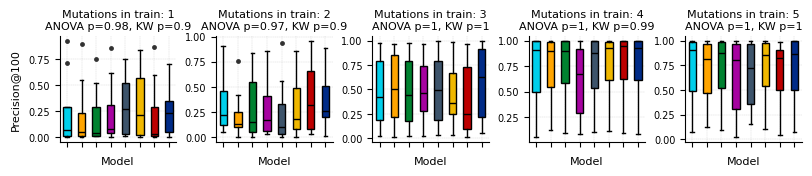

### F = 0.174, p = 0.984 (ANOVA) | Kruskal-Wallis H = 1.756, p = 0.972
### F = 0.094, p = 0.998 (ANOVA) | Kruskal-Wallis H = 1.933, p = 0.963
### F = 0.054, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.705, p = 0.998
### F = 0.027, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.888, p = 0.996
### F = 0.044, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.072, p = 0.994
### F = 0.036, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.252, p = 0.990


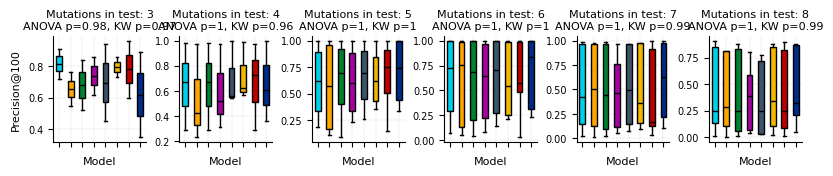


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/lov/lov_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.csv
Reading CSV 

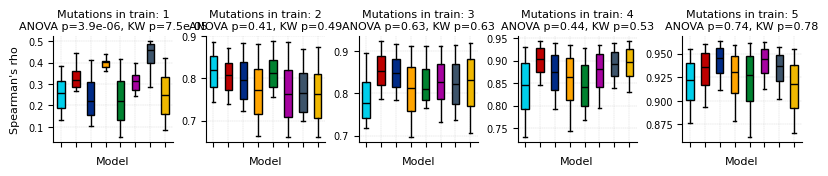

### F = 0.006, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.353, p = 1.000
### F = 0.012, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.307, p = 1.000
### F = 0.019, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.443, p = 1.000
### F = 0.024, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.378, p = 1.000
### F = 0.031, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.500, p = 0.999
### F = 0.037, p = 1.000 (ANOVA) | Kruskal-Wallis H = 0.685, p = 0.998


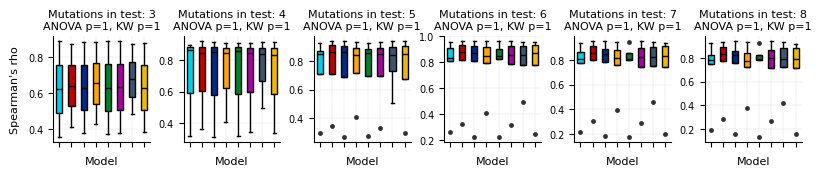


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks//data/pard3/pard3_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.

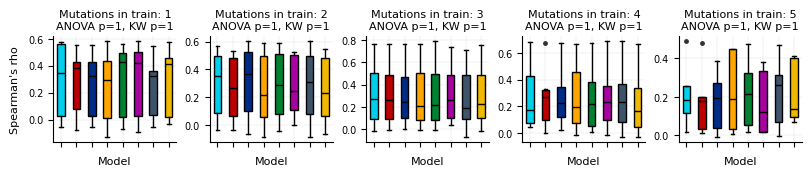

### F = 0.346, p = 0.910 (ANOVA) | Kruskal-Wallis H = 3.221, p = 0.864
### F = 0.055, p = 1.000 (ANOVA) | Kruskal-Wallis H = 1.147, p = 0.992
### F = 0.076, p = 0.999 (ANOVA) | Kruskal-Wallis H = 0.665, p = 0.999
### F = 1.072, p = 0.404 (ANOVA) | Kruskal-Wallis H = 6.483, p = 0.485
### F = 0.243, p = 0.971 (ANOVA) | Kruskal-Wallis H = 2.546, p = 0.924
### F = 0.495, p = 0.831 (ANOVA) | Kruskal-Wallis H = 3.480, p = 0.837


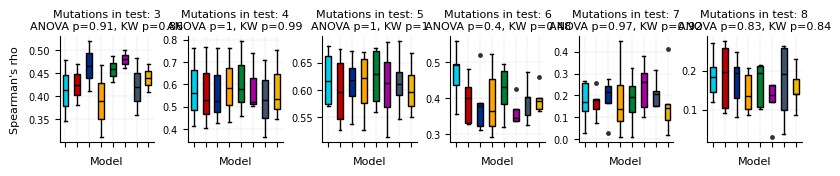

In [23]:

by_subsample_datasets = ["gfp", "lov", "pard3"]

features_per_dataset = {
    "gfp": ["precision", "recall", "f1", "roc", "accuracy", "top_100_pct"],
    "lov": ["correlation"],
    "pard3": ["correlation"]
}

all_dfs = []

fig_path = "./refined_figures/supp_figure_var_analysis/"
os.makedirs(fig_path, exist_ok=True)
for ds in by_subsample_datasets:
    embedding_base_dir = "%s/data/%s/%s_regression_optimal" % (base_path, ds, ds)
    df_all, ohe_df_all = load_df_all(embedding_base_dir, one_hot=True)
    all_dfs.append((ds, df_all, ohe_df_all))

    for feature in features_per_dataset[ds]:
        anova_agg = run_mut_comparision_anova_and_plot(
            df=df_all,
            dataset_name=ds,
            feature_name=feature,
            mutations=[1, 2, 3, 4, 5],
            mutation_factor_colname="train_mutations",
            results=anova_agg,
            do_plot=True,
            verbose=True,
            train=True,
            fig_path=os.path.join(fig_path, f"{ds}_{feature}_train_mutations.svg")
        )

        anova_agg = run_mut_comparision_anova_and_plot(
            df=df_all,
            dataset_name=ds,
            feature_name=feature,
            mutations=[3,4,5,6,7,8],
            mutation_factor_colname="test_mutations",
            results=anova_agg,
            do_plot=True,
            verbose=True,
            train=False,
            fig_path=os.path.join(fig_path, f"{ds}_{feature}_test_mutations.svg")
        )

In [24]:
#working_df["model_name"].unique()


var_explained_factor_results = []
for dataset_name, df_all, ohe_df_all in all_dfs:


    features_to_calculate_variance_for = features_per_dataset[dataset_name]
    working_df_pre_subset = df_all

    working_df = working_df_pre_subset[working_df_pre_subset["test_mutations"] <= 8]


    working_df["scale"] = np.nan

    for model_name in working_df["model_name"].unique():
        working_df.loc[working_df["model_name"] == model_name, "scale"] = discretized_parameter_scale[model_name]

    

    for tm in range(3, 9):
        sub_df = working_df[(working_df["test_mutations"] == tm) & (working_df["train_mutations"] >= 1)]
        ss_all, results_df = calculate_ss_for_df_and_factors(
            sub_df,
            factors=["model_name", "train_mutations", "scale"],
            variables_to_calculate=features_to_calculate_variance_for
        )

        for var in features_to_calculate_variance_for:#
            for factor in ["model_name", "train_mutations", "scale"]:
                ss_factor_for_var = results_df[(results_df["factor_name"] == factor) & (results_df["var"] == var)]["SS"].sum()
                total_ss_in_var = ss_all[ss_all["var"] == var]["SS"]
                

                var_explained_factor_results.append({"dataset": dataset_name,
                                                    "var": var, 
                                                    "factor": factor, 
                                                    "test_mutations": tm, 
                                                    "var_explained": (1 - ss_factor_for_var / total_ss_in_var).item()})


/tmp/ipykernel_466570/2433594040.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  working_df["scale"] = np.nan
/tmp/ipykernel_466570/2433594040.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  working_df["scale"] = np.nan
/tmp/ipykernel_466570/2433594040.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

In [25]:

pd.DataFrame(var_explained_factor_results)

,dataset,var,factor,test_mutations,var_explained
0,gfp,precision,model_name,3,0.003717
1,gfp,precision,train_mutations,3,0.993206
2,gfp,precision,scale,3,0.000543
3,gfp,recall,model_name,3,0.048663
4,gfp,recall,train_mutations,3,0.896199
...,...,...,...,...,...
139,pard3,correlation,train_mutations,7,0.687801
140,pard3,correlation,scale,7,0.004703
141,pard3,correlation,model_name,8,0.097769
142,pard3,correlation,train_mutations,8,0.674843


In [26]:

nmt_base_path = "%s/data/nmt/results/by_complexity_and_budget_up_to_11/" % base_path
gcn_base_path = "%s/data/gcn4/results/by_complexity_and_budget_up_to_8/" % base_path




nmt_sets = load_df_with_budget(nmt_base_path)
nmt_train = [5,6,7,8,9]
nmt_test = [9, 10, 11]

gcn_sets = load_df_with_budget(gcn_base_path)
gcn_train = [3,4,5,6]
gcn_test = [6, 7, 8]






In [27]:
factors = ["model_name", "budget", "max_muts_in_train"]

vars_and_func = {"gcn4" : lambda v: v.median(),
                 "nmt" : lambda v: np.percentile(v, 85)}#,


discretized_parameter_scale = {"esm_35m": "0_100",
                                "esm_8m": "0_100",
                                "esm_150m": "100_500",
                                "esm_650m": "500_1000",
                                "esm_3b": "500_1000",
                                "progen2-small": "100_500",
                                "progen2-medium": "500_1000",
                                "prot_bert": "100_500"}




results = []

all_sets = [("gcn4", gcn_sets), ("nmt", nmt_sets)]

for dataset_name, sets in all_sets:
    for held_out_set, df_tmp in sets.items():

        models = df_tmp["model_name"].unique()
        models = models[models != "one_hot"]
        
        #df_tmp = df[df["set_name"] == held_out_set]
        muts_sorted = sorted(df_tmp["max_muts_in_train"].unique())
        budgets_sorted = sorted(df_tmp["budget"].unique())

        for model_name in models:
            df_tmp_model = df_tmp[df_tmp["model_name"] == model_name]
            
            for b in budgets_sorted:
                for m in muts_sorted:
                    vals = df_tmp_model[(df_tmp_model["budget"] == b) & (
                                        df_tmp_model["max_muts_in_train"] == m)]["cor_llm"]

                    print(np.abs(vals))
                                        
                    metadata = {"model_name": model_name, 
                                "budget": b, 
                                "max_muts_in_train": m, 
                                #"muts_budget": f"m_{m}_b_{b}",
                                #"muts_model": f"m_{m}_mdl_{model_name}",
                                #"budget_model": f"b_{b}_mdl_{model_name}",
                                "dataset": dataset_name,
                                "set": held_out_set,
                                "scale": discretized_parameter_scale[model_name],
                                "cor_llm": vars_and_func[dataset_name]((vals))}

                    #statistics = {var: vars_and_func[var](vals) for var in vars}
                    results.append({**metadata})


rsdf =  pd.DataFrame(results)



0     0.290179
1     0.011670
2     0.220473
3     0.383342
4     0.167659
5     0.043818
6     0.260770
7     0.160582
8     0.189023
9     0.117415
10    0.140294
11    0.281222
12    0.271524
13    0.121275
14    0.268680
15    0.276672
16    0.268034
17    0.150147
18    0.205541
19    0.334651
20    0.136124
21    0.102916
22    0.136022
23    0.042336
24    0.148437
25    0.206816
26    0.060050
27    0.218882
28    0.066658
29    0.218825
Name: cor_llm, dtype: float64
180    0.103172
181    0.096714
182    0.121831
183    0.033097
184    0.032141
185    0.355000
186    0.204485
187    0.245583
188    0.208923
189    0.181736
190    0.287548
191    0.340260
192    0.210711
193    0.126630
194    0.023982
195    0.318615
196    0.299275
197    0.260284
198    0.098217
199    0.162889
200    0.025932
201    0.067628
202    0.165482
203    0.257822
204    0.084854
205    0.136867
206    0.218009
207    0.161560
208    0.103507
209    0.108361
Name: cor_llm, dtype: float64
360    0.0

In [28]:
rsdf

,model_name,budget,max_muts_in_train,dataset,set,scale,cor_llm
0,esm_8m,5,3,gcn4,held_out_6,0_100,0.142229
1,esm_8m,5,4,gcn4,held_out_6,0_100,0.141696
2,esm_8m,5,5,gcn4,held_out_6,0_100,0.133061
3,esm_8m,10,3,gcn4,held_out_6,0_100,0.115934
4,esm_8m,10,4,gcn4,held_out_6,0_100,0.249993
...,...,...,...,...,...,...,...
1291,prot_bert,50,6,nmt,held_out_11,100_500,-0.189464
1292,prot_bert,50,7,nmt,held_out_11,100_500,0.178571
1293,prot_bert,50,8,nmt,held_out_11,100_500,0.224821
1294,prot_bert,50,9,nmt,held_out_11,100_500,0.320000


In [29]:

var_explained_factor_results_with_budget = []
features = ["cor_llm"]
extended_factors = np.concatenate([factors, ["scale"]])  # , "muts_budget", "muts_model", "budget_model"]

# Updated to work for multiple datasets in rsdf
for dataset_name in rsdf["dataset"].unique():
    dataset_df = rsdf[rsdf["dataset"] == dataset_name]
    for held_out_set in dataset_df["set"].unique():
        print(held_out_set)
        ss_all, results_df = calculate_ss_for_df_and_factors(
            dataset_df[dataset_df["set"] == held_out_set],
            factors=extended_factors,
            variables_to_calculate=features
        )

        for var in features:
            for factor in extended_factors:
                ss_factor_for_var = results_df[
                    (results_df["factor_name"] == factor) & (results_df["var"] == var)
                ]["SS"].sum()
                total_ss_in_var = ss_all[ss_all["var"] == var]["SS"]

                var_explained_factor_results_with_budget.append({
                    "dataset": dataset_name,
                    "var": var,
                    "factor": factor,
                    "test_mutations": int(held_out_set.split("_")[-1]),
                    "var_explained": (1 - ss_factor_for_var / total_ss_in_var).item()
                })


held_out_6
held_out_7
held_out_8
held_out_9
held_out_10
held_out_11


In [30]:
pd.DataFrame(var_explained_factor_results_with_budget)

,dataset,var,factor,test_mutations,var_explained
0,gcn4,cor_llm,model_name,6,0.640839
1,gcn4,cor_llm,budget,6,0.012141
2,gcn4,cor_llm,max_muts_in_train,6,0.028200
3,gcn4,cor_llm,scale,6,0.187993
4,gcn4,cor_llm,model_name,7,0.334239
5,gcn4,cor_llm,budget,7,0.046285
6,gcn4,cor_llm,max_muts_in_train,7,0.057638
7,gcn4,cor_llm,scale,7,0.010817
8,gcn4,cor_llm,model_name,8,0.300917
9,gcn4,cor_llm,budget,8,0.074592


In [31]:
df_var_all = pd.concat(
    [pd.DataFrame(var_explained_factor_results),
     pd.DataFrame(var_explained_factor_results_with_budget)]
)

In [32]:
df_var_all

,dataset,var,factor,test_mutations,var_explained
0,gfp,precision,model_name,3,0.003717
1,gfp,precision,train_mutations,3,0.993206
2,gfp,precision,scale,3,0.000543
3,gfp,recall,model_name,3,0.048663
4,gfp,recall,train_mutations,3,0.896199
...,...,...,...,...,...
19,nmt,cor_llm,scale,10,0.000133
20,nmt,cor_llm,model_name,11,0.048005
21,nmt,cor_llm,budget,11,0.214537
22,nmt,cor_llm,max_muts_in_train,11,0.423719


### F = 2.316, p = 0.078 (ANOVA) | Kruskal-Wallis H = 11.947, p = 0.102
### F = 0.805, p = 0.595 (ANOVA) | Kruskal-Wallis H = 5.773, p = 0.566
### F = 2.556, p = 0.057 (ANOVA) | Kruskal-Wallis H = 11.053, p = 0.136
### F = 0.460, p = 0.849 (ANOVA) | Kruskal-Wallis H = 3.587, p = 0.826
### F = 0.066, p = 0.999 (ANOVA) | Kruskal-Wallis H = 3.265, p = 0.859


/tmp/ipykernel_466570/1551411289.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("nmt", nmt_sets, nmt_train, nmt_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).quantile(0.85)),
/tmp/ipykernel_466570/1551411289.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("nmt", nmt_sets, nmt_train, nmt_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).quantile(0.85)),
/tmp/ipykernel_466570/1551411289.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will def

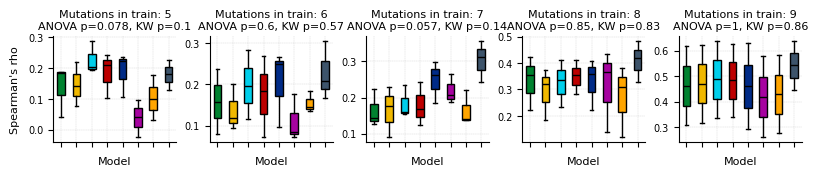

### F = 0.509, p = 0.819 (ANOVA) | Kruskal-Wallis H = 6.432, p = 0.490
### F = 0.137, p = 0.995 (ANOVA) | Kruskal-Wallis H = 3.931, p = 0.788
### F = 0.852, p = 0.552 (ANOVA) | Kruskal-Wallis H = 5.393, p = 0.612


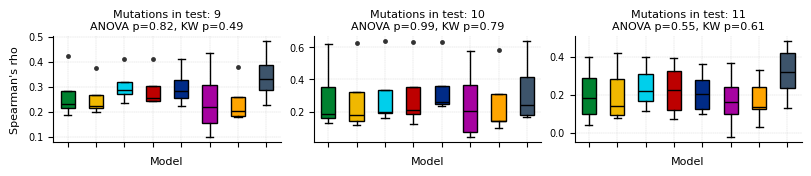

/tmp/ipykernel_466570/1551411289.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("gcn", gcn_sets, gcn_train, gcn_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).median())
/tmp/ipykernel_466570/1551411289.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ("gcn", gcn_sets, gcn_train, gcn_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).median())
/tmp/ipykernel_466570/1551411289.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Eithe

### F = 0.809, p = 0.592 (ANOVA) | Kruskal-Wallis H = 6.307, p = 0.504
### F = 1.309, p = 0.308 (ANOVA) | Kruskal-Wallis H = 9.307, p = 0.231
### F = 0.717, p = 0.659 (ANOVA) | Kruskal-Wallis H = 5.719, p = 0.573
### F = 19.933, p = 0.000 (ANOVA) | Kruskal-Wallis H = 13.147, p = 0.069


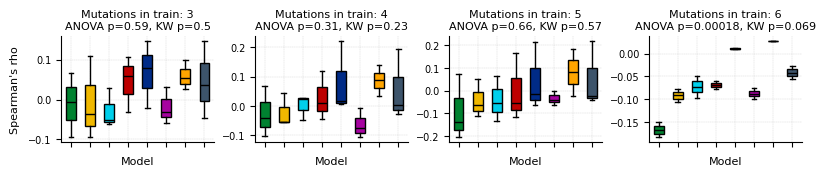

### F = 14.362, p = 0.000 (ANOVA) | Kruskal-Wallis H = 19.987, p = 0.006
### F = 10.130, p = 0.000 (ANOVA) | Kruskal-Wallis H = 23.749, p = 0.001
### F = 6.271, p = 0.000 (ANOVA) | Kruskal-Wallis H = 21.122, p = 0.004


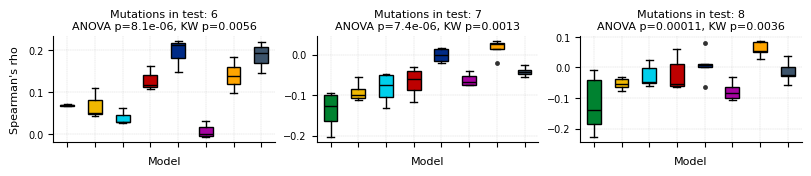

In [33]:

budgeted_sets = [
    ("nmt", nmt_sets, nmt_train, nmt_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).quantile(0.85)),
    ("gcn", gcn_sets, gcn_train, gcn_test, lambda df: df.groupby(["max_muts_in_train", "model_name"], as_index=False).median())
]


for name, sets, train, test, group_func in budgeted_sets:
    all_dfs = []
    for set_name, set_df in sets.items():
        grouped_df = group_func(set_df)
        grouped_df["set"] = int(set_name.split("_")[-1])
        all_dfs.append(grouped_df)
    all_dfs = pd.concat(all_dfs)
    all_dfs = all_dfs[all_dfs["model_name"] != "one_hot"]
    anova_agg = run_mut_comparision_anova_and_plot(
        df=all_dfs,
        dataset_name=name,
        feature_name="cor_llm",
        mutations=train,
        mutation_factor_colname="max_muts_in_train",
        results=anova_agg,
        do_plot=True,
        verbose=True,
        train=True,
        fig_path=os.path.join(fig_path, f"{name}_train_mutations.svg")
    )
    anova_agg = run_mut_comparision_anova_and_plot(
        df=all_dfs,
        dataset_name=name,
        feature_name="cor_llm",
        mutations=test,
        mutation_factor_colname="set",
        results=anova_agg,
        do_plot=True,
        verbose=True,
        train=False,
        fig_path=os.path.join(fig_path, f"{name}_test_mutations.svg")
    )



In [34]:
final_pvalue_df = pd.DataFrame(anova_agg)

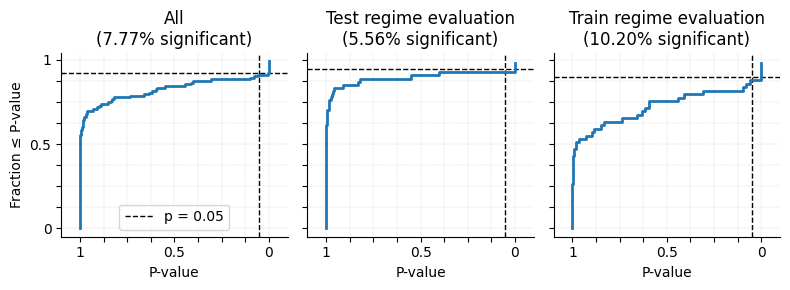

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

dfs = [
    final_pvalue_df,
    final_pvalue_df[final_pvalue_df["comparison_type"] == "test"],
    final_pvalue_df[final_pvalue_df["comparison_type"] == "train"]
]

titles = [
    "All",
    "Test regime evaluation",
    "Train regime evaluation"
]

for ax, df, title in zip(axes, dfs, titles):
    pvalues = df["P_value"].dropna().sort_values()
    cumulative = 1 - np.arange(1, len(pvalues) + 1) / len(pvalues)
    portion = 1 - sum(pvalues < 0.05) / len(pvalues)
    ax.set_xlabel("P-value")
    ax.set_title("%s\n(%.2f%% significant)" % (title, (1 - portion) * 100))
    ax.set_xticks([1, 0.5, 0])
    ax.set_xticklabels(['1', '0.5', '0'])
    ax.set_yticks([1, 0.5, 0])
    ax.set_yticklabels(['1', '0.5', '0'])
    ax.axvline(0.05, color='k', linestyle='dashed', lw="1", label='p = 0.05')
    if len(pvalues) > 0:
        ax.axhline(portion, color='k', linestyle='dashed', lw=1)
    ax.set_xlim(1.1, -0.1)
    ax.step(pvalues[::-1], cumulative[::-1], where="post", lw=2)
    ax.xaxis.set_major_locator(MultipleLocator(0.125))    
    ax.yaxis.set_major_locator(MultipleLocator(0.125))
    ax.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
    spines = ax.spines
    spines['right'].set_visible(False)
    spines['top'].set_visible(False)

axes[0].set_ylabel("Fraction ≤ P-value")
axes[0].legend()
plt.tight_layout()

# Save the figure to the specified figure path
fig.savefig(os.path.join(fig_path, "pvalue_fractions.png"), dpi=300)
plt.show()


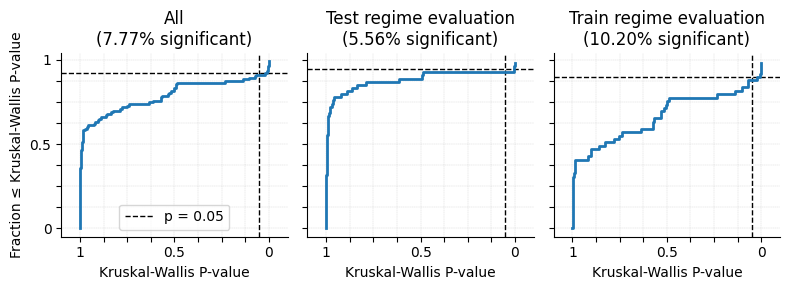

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

dfs = [
    final_pvalue_df,
    final_pvalue_df[final_pvalue_df["comparison_type"] == "test"],
    final_pvalue_df[final_pvalue_df["comparison_type"] == "train"]
]

titles = [
    "All",
    "Test regime evaluation",
    "Train regime evaluation"
]

for ax, df, title in zip(axes, dfs, titles):
    kruskal_pvalues = df["Kruskal_P"].dropna().sort_values()
    cumulative = 1 - np.arange(1, len(kruskal_pvalues) + 1) / len(kruskal_pvalues)
    portion = 1 - sum(kruskal_pvalues < 0.05) / len(kruskal_pvalues)
    ax.set_xlabel("Kruskal-Wallis P-value")
    ax.set_title("%s\n(%.2f%% significant)" % (title, (1 - portion) * 100))
    ax.set_xticks([1, 0.5, 0])
    ax.set_xticklabels(['1', '0.5', '0'])
    ax.set_yticks([1, 0.5, 0])
    ax.set_yticklabels(['1', '0.5', '0'])
    ax.axvline(0.05, color='k', linestyle='dashed', lw="1", label='p = 0.05')
    if len(kruskal_pvalues) > 0:
        ax.axhline(portion, color='k', linestyle='dashed', lw=1)
    ax.set_xlim(1.1, -0.1)
    ax.step(kruskal_pvalues[::-1], cumulative[::-1], where="post", lw=2)
    ax.xaxis.set_major_locator(MultipleLocator(0.125))    
    ax.yaxis.set_major_locator(MultipleLocator(0.125))
    ax.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
    spines = ax.spines
    spines['right'].set_visible(False)
    spines['top'].set_visible(False)

axes[0].set_ylabel("Fraction ≤ Kruskal-Wallis P-value")
axes[0].legend()
plt.tight_layout()

# Save the figure to the specified figure path
#fig.savefig(os.path.join(fig_path, "kruskal_pvalue_fractions.png"), dpi=300)
plt.show()


In [57]:
(final_pvalue_df["P_value"] < 0.05).sum() / 103

0.07766990291262135

,feature,comparison_type,mutations,dataset,F_value,P_value,Kruskal_H,Kruskal_P
0,precision,train,1,GFP,0.000007,1.000000,0.398202,0.999741
1,precision,train,2,GFP,0.000650,1.000000,0.746394,0.997953
2,precision,train,3,GFP,0.001580,1.000000,0.839957,0.997014
3,precision,train,4,GFP,0.002631,1.000000,0.500000,0.999446
4,precision,train,5,GFP,0.044427,0.999858,1.425366,0.984782
...,...,...,...,...,...,...,...,...
98,cor_llm,train,5,GCN4,0.717456,0.659111,5.719153,0.572898
99,cor_llm,train,6,GCN4,19.932512,0.000182,13.147059,0.068605
100,cor_llm,test,6,GCN4,14.362147,0.000008,19.986667,0.005599
101,cor_llm,test,7,GCN4,10.130312,0.000007,23.748762,0.001261


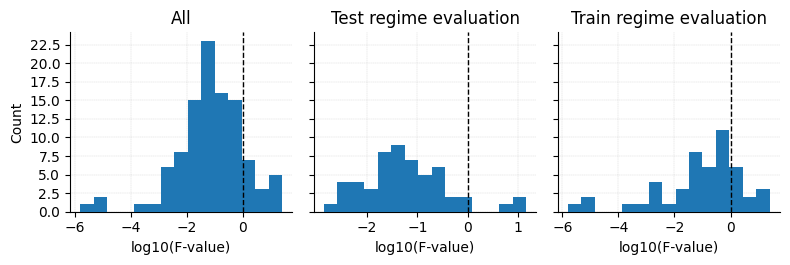

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(8, 2.75), sharey=True)

dfs = [
    final_pvalue_df,
    final_pvalue_df[final_pvalue_df["comparison_type"] == "test"],
    final_pvalue_df[final_pvalue_df["comparison_type"] == "train"]
]

titles = [
    "All",
    "Test regime evaluation",
    "Train regime evaluation"
]

xlabelticks = [
    [-6, -4, -2, 0],
    [-2, -1,  0, 1],
    [-6, -4, -2, 0]
]

for ax, df, title, xlabelticks in zip(axes, dfs, titles, xlabelticks):
    fvalues = np.log10(df["F_value"].dropna())
    # Plot the histogram first, so grid overlays it
    ax.hist(fvalues, bins=15, zorder=3)
    ax.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7, zorder=2)
    spines = ax.spines
    spines['right'].set_visible(False)
    spines['top'].set_visible(False)
    ax.set_xlabel("log10(F-value)")
    ax.axvline(0, lw="1", color="k", linestyle="dashed", zorder=3)
    ax.set_title(title)
    
    ax.set_xticks(xlabelticks)
    
    ax.yaxis.set_major_locator(MultipleLocator(2.5))    
    #ax.xaxis.set_major_locator(MultipleLocator(1))
axes[0].set_ylabel("Count")
plt.tight_layout()
fig.savefig(os.path.join(fig_path, "f_value_distribution.png"), dpi=300)
plt.show()


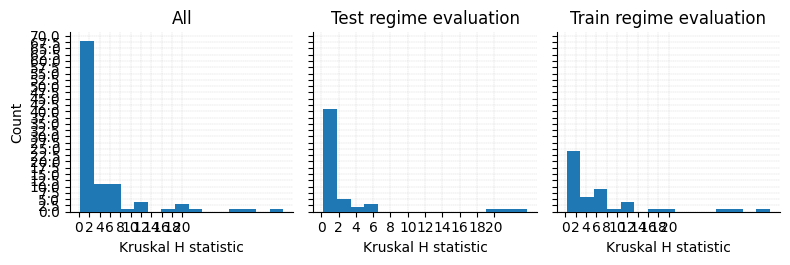

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(8, 2.75), sharey=True)

dfs = [
    final_pvalue_df,
    final_pvalue_df[final_pvalue_df["comparison_type"] == "test"],
    final_pvalue_df[final_pvalue_df["comparison_type"] == "train"]
]

titles = [
    "All",
    "Test regime evaluation",
    "Train regime evaluation"
]

xlabelticks = [
    [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
    [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
    [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
]

for ax, df, title, xticks in zip(axes, dfs, titles, xlabelticks):
    hvalues = df["Kruskal_H"].dropna()
    # Plot the histogram first, so grid overlays it
    ax.hist(hvalues, bins=15, zorder=3)
    ax.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7, zorder=2)
    spines = ax.spines
    spines['right'].set_visible(False)
    spines['top'].set_visible(False)
    ax.set_xlabel("Kruskal H statistic")
    ax.set_title(title)
    ax.set_xticks(xticks)
    ax.yaxis.set_major_locator(MultipleLocator(2.5))
axes[0].set_ylabel("Count")
plt.tight_layout()
#fig.savefig(os.path.join(fig_path, "kruskal_H_distribution.png"), dpi=300)
plt.show()


1

/tmp/ipykernel_466570/2604441289.py:42: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


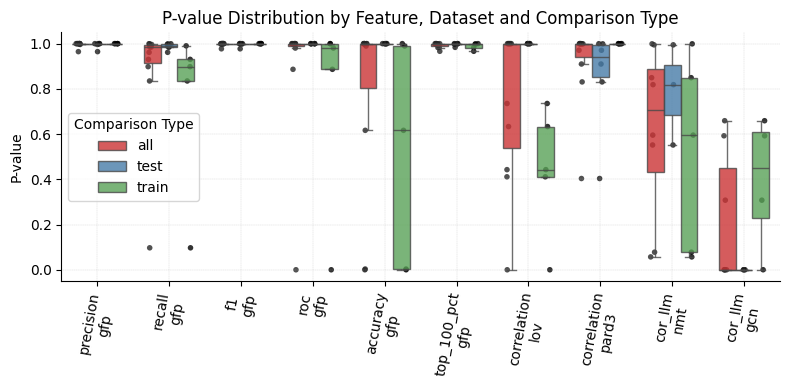

In [38]:
import seaborn as sns

plt.figure(figsize=(8, 4))

combo = final_pvalue_df[["feature", "dataset"]].drop_duplicates()
feature_dataset_order = combo.apply(lambda row: f"{row['feature']}\n{row['dataset']}", axis=1)

plot_df = []
for fd in feature_dataset_order:
    feature, dataset = fd.split("\n", 1)
    for comp_type in ["all", "test", "train"]:
        if comp_type == "all":
            mask = (final_pvalue_df["feature"] == feature) & (final_pvalue_df["dataset"] == dataset)
        else:
            mask = (final_pvalue_df["feature"] == feature) & (final_pvalue_df["dataset"] == dataset) & (final_pvalue_df["comparison_type"] == comp_type)
        for val in final_pvalue_df.loc[mask, "P_value"]:
            plot_df.append({
                "feature_dataset": fd,
                "comparison_type": comp_type,
                "P_value": (val)
            })
plot_df = pd.DataFrame(plot_df)
plot_df = plot_df[plot_df["comparison_type"].isin(["all", "test", "train"])]


# First draw boxplot
box = sns.boxplot(
    x="feature_dataset",
    y="P_value",
    hue="comparison_type",
    data=plot_df,
    order=feature_dataset_order,
    hue_order=["all", "test", "train"],
    width=0.7,
    dodge=True,
    palette="Set1",
    showfliers=False  # remove hollow outlier markers
    # zorder will not help as boxplot is artistically behind by default
)

# then draw stripplot, but move under boxplot using zorder and legend=False to avoid legend duplication
sns.stripplot(
    x="feature_dataset",
    y="P_value",
    hue="comparison_type",
    data=plot_df,
    order=feature_dataset_order,
    hue_order=["all", "test", "train"],
    dodge=True,
    marker="o",
    color="black",
    size=4,
    alpha=0.8,
    linewidth=0,
    zorder=0,      # puts below boxplot
    legend=False   # avoids duplicate legend handles
)

# Set boxplot opacity to 0.5 for all boxes and lines
for patch in box.patches:
    patch.set_alpha(0.8)

for line in box.lines:
    line.set_alpha(0.8)



plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7, zorder=2)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(rotation=80)
plt.ylabel("P-value")
plt.xlabel("")
plt.title("P-value Distribution by Feature, Dataset and Comparison Type")
# Adjust legend to avoid duplicate handles/labels
handles, labels = plt.gca().get_legend_handles_labels()
n = len(set(plot_df["comparison_type"]))
plt.legend(handles[:n], labels[:n], title="Comparison Type")
plt.tight_layout()
plt.show()


/tmp/ipykernel_466570/2627059528.py:100: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


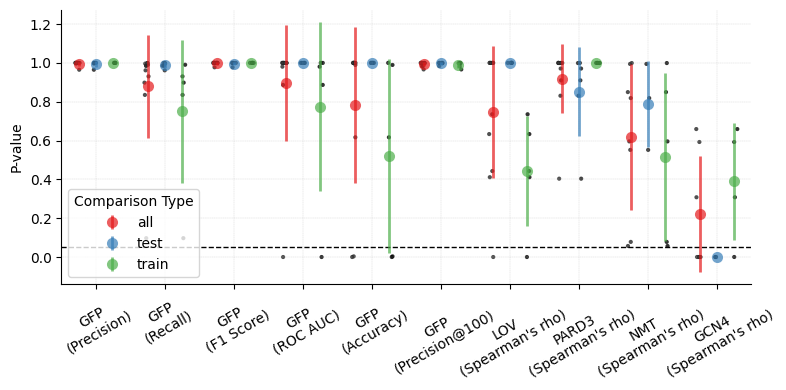

In [72]:

import seaborn as sns

# Consistent naming as in file_context_0
final_pvalue_df = final_pvalue_df.copy()
final_pvalue_df.loc[final_pvalue_df["dataset"] == "gfp", "dataset"] = "GFP"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "pard3", "dataset"] = "PARD3"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "nmt", "dataset"] = "NMT"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "gcn", "dataset"] = "GCN4"
final_pvalue_df.loc[final_pvalue_df["dataset"] == "lov", "dataset"] = "LOV"

plt.figure(figsize=(8, 4))

# Prepare label mapping for pretty axis labels as in file_context_0
combo = final_pvalue_df[["feature", "dataset"]].drop_duplicates()

# Compose x-axis label formatting similar to file_context_0:
# Build a mapping from variable name to a y_label (if available)
# For this context, let's prepare a dictionary mapping "feature" to a display name
# If you have a ylabel_dict already loaded, use that, else just use the raw string
try:
    display_label_dict = ylabel_dict
except NameError:
    display_label_dict = {}

# Compose two sets of labels for optional use
# 1. Default: feature (variable) \n DATASET (capitalized)
feature_dataset_order = combo.apply(lambda row: f"{row['feature']}\n{row['dataset']}", axis=1)

# 2. Prettier style: DATASET\n(feature label) (as in file_context_0)
def get_ylabel(feat):
    return display_label_dict.get(feat, feat.replace("_", " ").title())

feature_dataset_order_y_label = combo.apply(
    lambda row: f"{row['dataset']}\n({get_ylabel(row['feature'])})", axis=1
)

# Use this for all ordering/plotting to be consistent
plot_order = feature_dataset_order
plot_xticks = feature_dataset_order_y_label

plot_df = []
for fd, pretty_label in zip(plot_order, plot_xticks):
    feature, dataset = fd.split("\n", 1)
    for comp_type in ["all", "test", "train"]:
        if comp_type == "all":
            mask = (final_pvalue_df["feature"] == feature) & (final_pvalue_df["dataset"] == dataset)
        else:
            mask = (
                (final_pvalue_df["feature"] == feature)
                & (final_pvalue_df["dataset"] == dataset)
                & (final_pvalue_df["comparison_type"] == comp_type)
            )
        for val in final_pvalue_df.loc[mask, "P_value"]:
            plot_df.append({
                "feature_dataset": fd,  # use raw for x axis order (must match 'order')
                "feature_dataset_y": pretty_label,  # for legend or xticks if needed
                "comparison_type": comp_type,
                "P_value": val
            })
plot_df = pd.DataFrame(plot_df)
plot_df = plot_df[plot_df["comparison_type"].isin(["all", "test", "train"])]
plot_df = plot_df[plot_df["feature_dataset"].isin(plot_order)]

# Compute summary statistics per feature_dataset and comparison_type
summary = plot_df.groupby(['feature_dataset', 'comparison_type'])['P_value'].agg(
    mean='mean', std='std'
).reset_index()

comparison_types = ["all", "test", "train"]
colors = sns.color_palette('Set1', n_colors=3)
color_map = dict(zip(comparison_types, colors))

width = 0.25
dodge_pos = dict(zip(comparison_types, [-width, 0, width]))

# Plot mean/std (errorbar) per type in colored dots, overlaid with stripplot of all points in black
for i, (fd, pretty_label) in enumerate(zip(plot_order, plot_xticks)):
    for comp_type in comparison_types:
        sub = summary[(summary['feature_dataset'] == fd) & (summary['comparison_type'] == comp_type)]
        if sub.empty:
            continue
        mean = sub['mean'].values[0]
        std = sub['std'].values[0]
        plt.errorbar(
            i + dodge_pos[comp_type], mean,
            yerr=std if not pd.isna(std) else 0.0,
            fmt='o',
            markersize=8,
            color=color_map[comp_type],
            elinewidth=2,
            capsize=1,
            alpha=0.7,
            markeredgewidth=0,
            markeredgecolor="black",
            label=comp_type if (i == 0) else "",
            zorder=4
        )

# Underlay all individual P-values as a stripplot (using black points)
sns.stripplot(
    x="feature_dataset",
    y="P_value",
    hue="comparison_type",
    data=plot_df,
    order=plot_order,
    hue_order=["all", "test", "train"],
    dodge=0.3,
    marker="o",
    color="black",
    size=3,
    alpha=0.8,
    linewidth=0,
    zorder=0,
    legend=False
)

plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# Use x-ticks with "pretty" axis labels, similar to file_context_0:
plt.xticks(
    range(len(plot_order)),
    plot_xticks,
    rotation=30  # match file_context_0 for easier side reading, not 80!
)
plt.ylabel("P-value")
plt.xlabel("")
plt.axhline(0.05, color='k', linestyle='dashed', lw=1)

# Show unique legend only
handles, labels = plt.gca().get_legend_handles_labels()
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Comparison Type")
plt.tight_layout()
#plt.title("P-value Distribution by Feature and Dataset")
#plt.savefig(os.path.join(fig_path, "pvalue_distribution_by_feature_and_dataset.png"), dpi=300)
plt.show()


In [40]:
fig_path

'./refined_figures/supp_figure_var_analysis/'

In [41]:
df_var_all.loc[df_var_all["factor"] == "max_muts_in_train", "factor"] = "train_mutations"
df_var_all.loc[df_var_all["dataset"] == "gfp", "dataset"] = "GFP"
df_var_all.loc[df_var_all["dataset"] == "pard3", "dataset"] = "PARD3"
df_var_all.loc[df_var_all["dataset"] == "nmt", "dataset"] = "NMT"
df_var_all.loc[df_var_all["dataset"] == "gcn4", "dataset"] = "GCN4"
df_var_all.loc[df_var_all["dataset"] == "lov", "dataset"] = "LOV"



df_var_all["y_label"] = [ylabel_dict[var] for var in df_var_all["var"]]




In [42]:
df_var_all

,dataset,var,factor,test_mutations,var_explained,y_label
0,GFP,precision,model_name,3,0.003717,Precision
1,GFP,precision,train_mutations,3,0.993206,Precision
2,GFP,precision,scale,3,0.000543,Precision
3,GFP,recall,model_name,3,0.048663,Recall
4,GFP,recall,train_mutations,3,0.896199,Recall
...,...,...,...,...,...,...
19,NMT,cor_llm,scale,10,0.000133,Spearman's rho
20,NMT,cor_llm,model_name,11,0.048005,Spearman's rho
21,NMT,cor_llm,budget,11,0.214537,Spearman's rho
22,NMT,cor_llm,train_mutations,11,0.423719,Spearman's rho


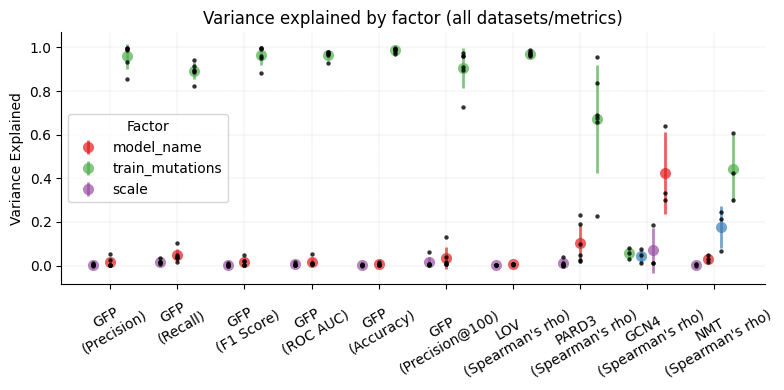

In [43]:
import seaborn as sns

# Prepare feature-dataset labeling and data
df = df_var_all
combo = df[["var", "dataset"]].drop_duplicates()
feature_dataset_order = combo.apply(lambda row: f"{row['var']}\n{row['dataset']}", axis=1)
combo_y_label = df[["y_label", "dataset"]].drop_duplicates()
feature_dataset_order_y_label = combo_y_label.apply(lambda row: f"{row['dataset']}\n({row['y_label']})", axis=1)

plot_df = []
for fd in feature_dataset_order:
    var, dataset = fd.split("\n", 1)
    comp_types = sorted(df.loc[(df['var'] == var) & (df['dataset'] == dataset), 'factor'].unique())
    for factor in comp_types:
        mask = (df["var"] == var) & (df["dataset"] == dataset) & (df["factor"] == factor)
        for val in df.loc[mask, "var_explained"]:
            plot_df.append({
                "feature_dataset": fd,
                "factor": factor,
                "var_explained": val
            })

plot_df = pd.DataFrame(plot_df)

# Compute mean and std for error bars
summary = plot_df.groupby(['feature_dataset', 'factor'])['var_explained'].agg(
    mean='mean', std='std'
).reset_index()

# Set colors: assign a fixed palette based on the full list of all possible factors, so color is always mapped in the same way
# Fix the order of all possible factors to keep color mapping stable
all_possible_factors = [
    "model_name", "budget", "train_mutations", "scale"
    # Add other factors you know of (even if not in all comparisons)
]
all_factors_present = [f for f in all_possible_factors if f in plot_df['factor'].unique()]
color_palette = sns.color_palette('Set1', n_colors=len(all_factors_present))
color_map = dict(zip(all_factors_present, color_palette))

# For each feature-dataset, get all factors and their stds; build dodge offsets based on std "ascending" order
fd_to_factors = {}
fd_to_n_factors = {}
fd_to_sorted_factors = {}
fd_to_dodge = {}

for fd in feature_dataset_order:
    # Get all present factors for this feature-dataset
    factors = [f for f in all_factors_present if not summary[(summary['feature_dataset'] == fd) & (summary['factor'] == f)].empty]
    # Get std for these factors (use 0 if none present, shouldn't happen)
    stds = [
        summary.loc[(summary['feature_dataset'] == fd) & (summary['factor'] == factor), 'std'].values[0] if
        not summary.loc[(summary['feature_dataset'] == fd) & (summary['factor'] == factor), 'std'].empty else 0.0
        for factor in factors
    ]
    # Order the factors for this subgroup by ascending std
    factors_sorted = [f for _, f in sorted(zip(stds, factors), key=lambda t: t[0])]
    fd_to_factors[fd] = factors_sorted
    fd_to_n_factors[fd] = len(factors_sorted)
    # Now assign dodge offsets: keep them centered/ordered by sorted factors for each category
    n_types = len(factors_sorted)
    width = 0.18 if n_types > 3 else 0.25
    fd_to_dodge[fd] = dict(
        zip(
            factors_sorted,
            [width * (i - (n_types - 1) / 2) for i in range(n_types)]
        )
    )
    fd_to_sorted_factors[fd] = factors_sorted

fig = plt.figure(figsize=(8, 4))

for i, fd in enumerate(feature_dataset_order):
    x_base = i
    factors_sorted = fd_to_sorted_factors[fd]
    dodge_pos = fd_to_dodge[fd]
    # Plot error bars for means +/- std (factors ordered by error bar size, lowest first)
    for factor in factors_sorted:
        sub = summary[(summary['feature_dataset'] == fd) & (summary['factor'] == factor)]
        if sub.empty:
            continue
        mean = sub['mean'].values[0]
        std = sub['std'].values[0]
        plt.errorbar(
            x_base + dodge_pos[factor], mean,
            yerr=std if not pd.isna(std) else 0.0,
            fmt='o',
            markersize=8,
            color=color_map[factor],
            elinewidth=2,
            capsize=1,
            alpha=0.7,
            markeredgewidth=0,
            markeredgecolor="black",
            # Only add label for first group with this factor, so legend is not duplicated
            label=factor if (i == 0 and factor in all_factors_present) else "",
            zorder=0
        )

    # Overlay all scatter points for each (jittered/dodged, order matches errorbar order in group)
    for factor in factors_sorted:
        sub_points = plot_df[(plot_df['feature_dataset'] == fd) & (plot_df['factor'] == factor)]
        x_vals = [x_base + dodge_pos[factor]] * len(sub_points)
        plt.scatter(
            x_vals,
            sub_points['var_explained'],
            color="black",
            s=10,
            alpha=0.8,
            lw=0,
            zorder=2
        )

# Set x-ticks to match default 1.0 spacing
tick_locations = list(range(len(feature_dataset_order)))
plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(tick_locations, feature_dataset_order_y_label, rotation=30)
plt.ylabel("Variance Explained")
plt.xlabel("")
plt.title("Variance explained by factor (all datasets/metrics)")

from collections import OrderedDict

# sort legend as before
handles, labels = plt.gca().get_legend_handles_labels()
factor_label_to_handle = {lbl: hand for hand, lbl in zip(handles, labels)}
ordered_handles = []
ordered_labels = []
for factor in all_factors_present:
    if factor in factor_label_to_handle:
        ordered_handles.append(factor_label_to_handle[factor])
        ordered_labels.append(factor)
plt.legend(ordered_handles, ordered_labels, title="Factor")
plt.tight_layout()
plt.show()


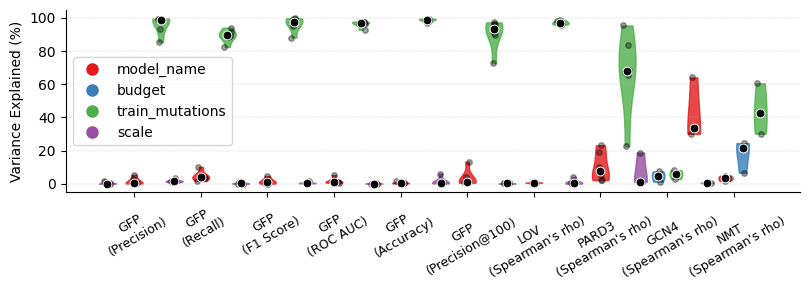

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assume df_var_all is already loaded
df = df_var_all.copy()

# Multiply variance explained by 100 to get percent
df["var_explained"] = df["var_explained"] * 100

# Build unique var-dataset combos
combo = df[["var", "dataset"]].drop_duplicates().reset_index(drop=True)
combo["var_dataset"] = combo.apply(lambda r: f"{r['var']}\n{r['dataset']}", axis=1)
df = df.merge(combo, on=["var", "dataset"], how="left")

# Prepare x-label order and pretty y-labels
feature_dataset_order = combo["var_dataset"].tolist()
combo_y_label = combo.merge(df[["var", "dataset", "y_label"]].drop_duplicates(), on=["var", "dataset"], how="left")
feature_dataset_order_y_label = combo_y_label.apply(lambda row: f"{row['dataset']}\n({row['y_label']})", axis=1).tolist()

# Define all known factor types; extend if needed
all_possible_factors = ["model_name", "budget", "train_mutations", "scale"]
factor_colors = sns.color_palette('Set1', n_colors=len(all_possible_factors))
factor_color_map = dict(zip(all_possible_factors, factor_colors))

# For each var_dataset combo, get sorted factor order by median var_explained (smallest-to-largest)
factor_orders_per_combo = {}
for vds in feature_dataset_order:
    _df = df[df["var_dataset"] == vds]
    factor_medians = {
        factor: _df.loc[_df["factor"] == factor, "var_explained"].median()
        for factor in _df["factor"].unique()
    }
    # Sort factors for this combo by median
    ordered_factors = sorted(factor_medians, key=lambda k: (factor_medians[k], k))
    factor_orders_per_combo[vds] = ordered_factors

# Set up canvas (match intended width)
fig, ax = plt.subplots(figsize=(8.2 , 3))

violin_width = 0.8 # total width for all violin groups at each var_dataset
scatter_alpha = 0.35
center_median_marker_size = 40

# X locations are integer-aligned by var_dataset
x_ticks = np.arange(len(feature_dataset_order))

for x_pos, vds in enumerate(feature_dataset_order):
    vdf = df[df["var_dataset"] == vds].copy()
    factors = factor_orders_per_combo[vds]
    n_factors = len(factors)
    # Violin midpoints for factors (centered about x integer position)
    offset_vec = np.linspace(-violin_width/2, violin_width/2, n_factors)

    for i, (factor, off) in enumerate(zip(factors, offset_vec)):
        sub = vdf[vdf["factor"] == factor]
        vals = sub["var_explained"].dropna().values
        _color = factor_color_map.get(factor, "gray")

        if len(vals) > 0:
            # Instead of seaborn's violinplot, use ax.violinplot.
            # ax.violinplot does not support unique y/positions per call, so we plot one at a time.
            parts = ax.violinplot(
                [vals], positions=[x_pos + off],
                widths=violin_width / n_factors * 0.95,
                showmeans=False, showmedians=False, showextrema=False
            )
            for pc in parts['bodies']:
                pc.set_facecolor(_color)
                pc.set_edgecolor(_color)
                pc.set_alpha(0.8)

            # Jitter actual points around the center of this violin
            jx = np.random.normal(loc=x_pos + off, scale=(violin_width / n_factors)*0.10, size=len(vals))
            ax.scatter(jx, vals, color="black", alpha=scatter_alpha, s=16, zorder=2)

            # Overlay median value in black, centered
            median = np.median(vals)
            ax.scatter([x_pos + off], [median], color="black", s=center_median_marker_size, zorder=4,
                       marker="o", edgecolor="white", linewidth=0.7)

# X ticks: one per var_dataset, pretty label
ax.set_xticks(x_ticks)
ax.set_xticklabels(feature_dataset_order_y_label, rotation=30, fontsize=9)

# Prepare ordered legend as in plot, without duplicates
seen = set()
legend_handles = []
legend_labels = []
for f in all_possible_factors:
    if any(f in factor_orders_per_combo[vds] for vds in feature_dataset_order) and f not in seen:
        seen.add(f)
        color = factor_color_map.get(f, "gray")
        h = plt.Line2D([0], [0], color=color, marker="o", linestyle="", markersize=8, label=f)
        legend_handles.append(h)
        legend_labels.append(f)
ax.legend(legend_handles, legend_labels)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Variance Explained (%)")
ax.set_xlabel("")
ax.grid(True, axis='y', linestyle='--', linewidth=0.3, alpha=0.7)
plt.tight_layout()
#plt.show()


save_dir = "./refined_figures"
os.makedirs(save_dir, exist_ok=True)
fig_path = os.path.join(save_dir, "figure_models_comparision/variance_explained_by_factor.svg")
plt.savefig(fig_path, format='svg', bbox_inches="tight")
plt.show()





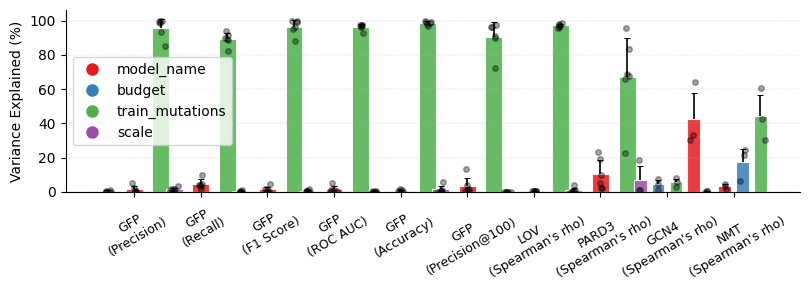

In [45]:

# Assume df_var_all is already loaded
df = df_var_all.copy()

# Multiply variance explained by 100 to get percent
df["var_explained"] = df["var_explained"] * 100

# Build unique var-dataset combos
combo = df[["var", "dataset"]].drop_duplicates().reset_index(drop=True)
combo["var_dataset"] = combo.apply(lambda r: f"{r['var']}\n{r['dataset']}", axis=1)
df = df.merge(combo, on=["var", "dataset"], how="left")

# Prepare x-label order and pretty y-labels
feature_dataset_order = combo["var_dataset"].tolist()
combo_y_label = combo.merge(df[["var", "dataset", "y_label"]].drop_duplicates(), on=["var", "dataset"], how="left")
feature_dataset_order_y_label = combo_y_label.apply(lambda row: f"{row['dataset']}\n({row['y_label']})", axis=1).tolist()

# Define all known factor types
all_possible_factors = ["model_name", "budget", "train_mutations", "scale"]
factor_colors = sns.color_palette('Set1', n_colors=len(all_possible_factors))
factor_color_map = dict(zip(all_possible_factors, factor_colors))

# For each var_dataset combo, get sorted factor order by median var_explained (smallest-to-largest)
factor_orders_per_combo = {}
for vds in feature_dataset_order:
    _df = df[df["var_dataset"] == vds]
    factor_medians = {
        factor: _df.loc[_df["factor"] == factor, "var_explained"].median()
        for factor in _df["factor"].unique()
    }
    # Sort factors for this combo by median
    ordered_factors = sorted(factor_medians, key=lambda k: (factor_medians[k], k))
    factor_orders_per_combo[vds] = ordered_factors

# Set up canvas for barplot version
fig, ax = plt.subplots(figsize=(8.2, 3))

bar_width = 0.8  # total width for all bars at each var_dataset
scatter_alpha = 0.35
center_median_marker_size = 40
errorbar_linewidth = 1.2

# X locations are integer-aligned by var_dataset
x_ticks = np.arange(len(feature_dataset_order))

for x_pos, vds in enumerate(feature_dataset_order):
    vdf = df[df["var_dataset"] == vds].copy()
    factors = factor_orders_per_combo[vds]
    n_factors = len(factors)
    # Bar midpoints for factors (centered about x integer position)
    offset_vec = np.linspace(-bar_width/2, bar_width/2, n_factors)
    
    for i, (factor, off) in enumerate(zip(factors, offset_vec)):
        sub = vdf[vdf["factor"] == factor]
        vals = sub["var_explained"].dropna().values
        _color = factor_color_map.get(factor, "gray")

        if len(vals) > 0:
            mean = np.mean(vals)
            std = np.std(vals)
            bar_x = x_pos + off

            # Plot bar up to mean
            ax.bar(bar_x, mean, 
                   width=bar_width / n_factors * 0.95, 
                   color=_color, 
                   alpha=0.85,
                   zorder=1,
                   edgecolor="white",
                   linewidth=0.8)

            # Plot error bar: only +std as a thin black line, starting at mean
            # We plot a vertical black line from mean to mean+std if std > 0
            if std > 0:
                ax.vlines(bar_x, mean, mean + std, colors='black', linestyles='-', lw=errorbar_linewidth, zorder=3)
                # Optionally a small cap at the top
                ax.hlines(mean + std, bar_x - 0.045, bar_x + 0.045, colors='black', lw=0.7, zorder=3)

            # Jitter actual points around the center of this bar
            jx = np.random.normal(loc=bar_x, scale=(bar_width / n_factors)*0.10, size=len(vals))
            ax.scatter(jx, vals, color="black", alpha=scatter_alpha, s=16, zorder=4)

            # Overlay median value in black, centered
            # median = np.median(vals)
            # ax.scatter([bar_x], [median], color="black", s=center_median_marker_size, zorder=5,
            #            marker="o", edgecolor="white", linewidth=0.7)

# X ticks: one per var_dataset, pretty label
ax.set_xticks(x_ticks)
ax.set_xticklabels(feature_dataset_order_y_label, rotation=30, fontsize=9)

# Prepare ordered legend as in plot, without duplicates
seen = set()
legend_handles = []
legend_labels = []
for f in all_possible_factors:
    if any(f in factor_orders_per_combo[vds] for vds in feature_dataset_order) and f not in seen:
        seen.add(f)
        color = factor_color_map.get(f, "gray")
        h = plt.Line2D([0], [0], color=color, marker="o", linestyle="", markersize=8, label=f)
        legend_handles.append(h)
        legend_labels.append(f)
ax.legend(legend_handles, legend_labels)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Variance Explained (%)")
ax.set_xlabel("")
ax.grid(True, axis='y', linestyle='--', linewidth=0.3, alpha=0.7)
plt.tight_layout()
#plt.show()

save_dir = "./refined_figures"
os.makedirs(save_dir, exist_ok=True)
fig_path = os.path.join(save_dir, "figure_models_comparision/variance_explained_by_factor_barplot.svg")
plt.savefig(fig_path, format='svg', bbox_inches="tight")
plt.show()

